# sin파 하중(강제진동)을 받는 M, C, K 시스템의 응답


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 시스템 패러미터

m = 1  # 질량
k = 1  # 강성
c = 0.05  # 감쇠

In [3]:

# 고유 진동수와 감쇠비
wn = np.sqrt(k / m)
xi = c / (2 * np.sqrt(m * k))  #감쇠비
wd = wn * np.sqrt(1 - xi ** 2)

In [4]:
print(xi)

0.025


In [5]:
print(wn)

1.0


In [6]:
# 시간 설정
t = np.linspace(0, 150, 1000)  # 0초에서 150초까지 1000개의 시간점

In [7]:
# 초기조건 입력
x0 = 1
v0 = 1


In [8]:
# 강제진동 입력
wf = 0.3    # 외력의 진동수
F0 = 1      # 외력의 진폭

In [9]:
# 자유진동
Uc = np.exp(-xi * wn * t)*(x0 * np.cos(wd * t) + (v0 + xi * wn * x0) / wd * np.sin(wd * t))


In [10]:
A = np.sqrt(x0**2 + ((v0 + xi * wn * x0) / wd)**2)
env_upper = A * np.exp(-xi * wn * t)
env_lower = -A * np.exp(-xi * wn * t)

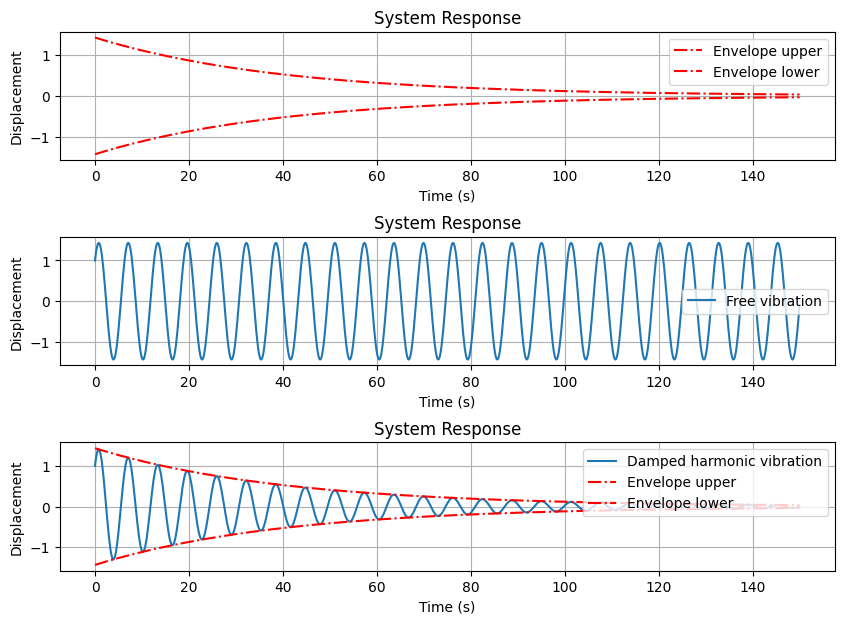

In [11]:
plt.figure(figsize=(10, 7))
plt.subplot(3,1,1)
plt.plot(t,env_upper,'r-.',label ='Envelope upper')
plt.plot(t,env_lower,'r-.',label ='Envelope lower')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.title('System Response')
plt.legend()
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, x0 * np.cos(wd * t) + (v0 + xi * wn * x0) / wd * np.sin(wd * t), label='Free vibration')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.title('System Response')
plt.legend()
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, Uc, label='Damped harmonic vibration')
plt.plot(t,env_upper,'r-.',label ='Envelope upper')
plt.plot(t,env_lower,'r-.',label ='Envelope lower')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.title('System Response')
plt.legend(loc='upper right')
plt.grid()

plt.subplots_adjust(hspace=0.6)
plt.show()

In [12]:
a = F0*(k-m*wf**2)/((k-m*wf**2)**2+(2*c*wf)**2)
b = -F0*2*c*wf/((k-m*wf**2)**2+(2*c*wf)**2)

In [13]:
print(a,b)

1.097708082026538 -0.0361881785283474


In [14]:
Up = a*np.sin(wf*t)+b*np.cos(wf*t)

In [15]:
# 강제진동 (sin파로 가정)

a = F0*(k-m*wf**2)/((k-m*wf**2)**2+(2*c*wf)**2)
b = -F0*2*c*wf/((k-m*wf**2)**2+(2*c*wf)**2)
phase = np.arctan2(a,b)

mag = np.sqrt(a**2+b**2)
#mag = F0/k/np.sqrt((1-wf**2/wn**2)**2+(2*xi*wf/wn)**2)

Up = mag*np.cos(wf*t-phase)

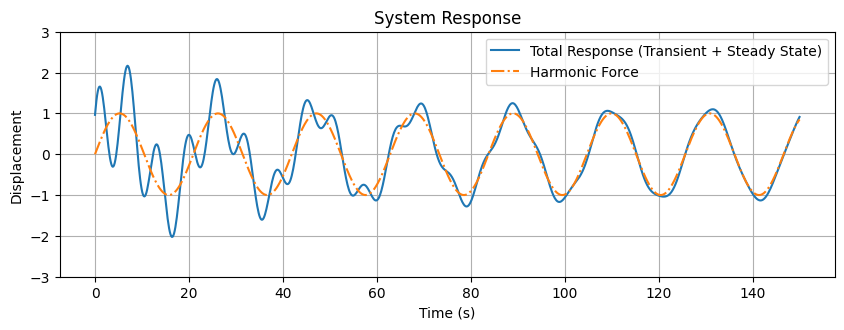

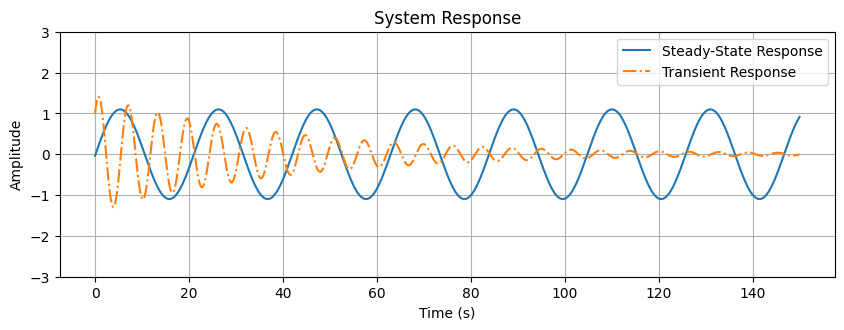

In [16]:
plt.figure(figsize=(10, 7))
plt.subplot(2,1,1)
plt.plot(t, Uc+Up, label='Total Response (Transient + Steady State)')
plt.plot(t,np.sin(wf*t),'-.',label ='Harmonic Force')
plt.ylim(-3,3)
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.title('System Response')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 7))
plt.subplot(2,1,2)
plt.plot(t, Up, label='Steady-State Response')
plt.plot(t, Uc, '-.', label='Transient Response')
plt.ylim(-3,3)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('System Response')
plt.legend()
plt.grid()
plt.show()

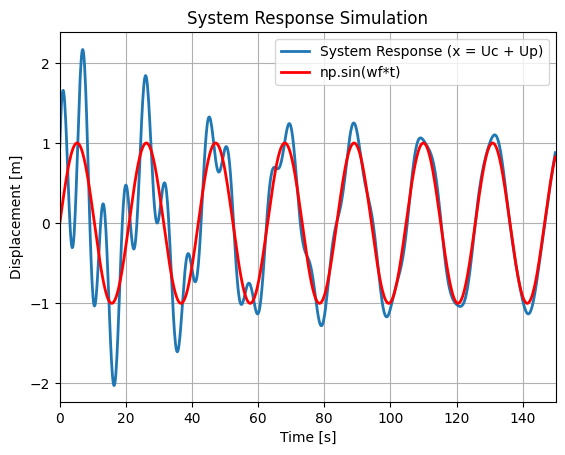

In [17]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# wf: np.sin(wf*t)를 위한 각진동수 (원하는 값으로 조정)


# Uc와 Up는 이미 계산되어 있다고 가정 (예: Uc, Up는 numpy 배열)
x = Uc + Up           # 실제 계산: x = Uc + Up

# t 배열: 0초에서 150초까지 1000개의 시간점
t = np.linspace(0, 150, 1000)

fig, ax = plt.subplots()
ax.set_title("System Response Simulation")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Displacement [m]")
ax.grid(True)

# 시스템 응답(x)와 np.sin(wf*t)를 위한 두 개의 선 객체 생성
line, = ax.plot([], [], lw=2, label='System Response (x = Uc + Up)')
line2, = ax.plot([], [], lw=2, color='red', label='np.sin(wf*t)')

ax.legend()

# 축 범위 설정: 두 곡선의 최소, 최대값을 고려합니다.
y_min = min(np.min(x), np.min(np.sin(wf*t)))
y_max = max(np.max(x), np.max(np.sin(wf*t)))
ax.set_xlim(t[0], t[-1])
ax.set_ylim(y_min - 0.1*abs(y_min), y_max + 0.1*abs(y_max))

def init():
    line.set_data([], [])
    line2.set_data([], [])
    return line, line2

def animate(frame):
    # 현재 프레임까지의 데이터를 업데이트합니다.
    line.set_data(t[:frame], x[:frame])
    line2.set_data(t[:frame], np.sin(wf * t[:frame]))
    return line, line2

# FuncAnimation을 사용해 애니메이션 생성 (interval은 프레임 간 간격 [ms])
ani = FuncAnimation(fig, animate, frames=len(t), init_func=init, blit=True, interval=10)

# Colab에서 HTML5 비디오로 애니메이션 출력
HTML(ani.to_html5_video())


# 동적증폭계수 그리기

In [18]:
#정적변위
Ust = F0/k
print("Static Displacement: ", Ust)

Static Displacement:  1.0


In [19]:
wf = np.arange(0.01,5,0.01)  # 외력의 진동수 범위: 0.01 ~ 5 까지 0.01간격
xi = np.arange(0.01,0.1,0.02)  # 감쇠비 범위: 1% ~10%, 2% 간격

daf =np.zeros((len(wf),len(xi)))

for i in range(len(wf)):
  for j in range(len(xi)):
    daf[i,j] = (1/np.sqrt((1-(wf[i]/wn)**2)**2+(2*xi[j]*wf[i]/wn)**2))  # 동적증폭계수 계산



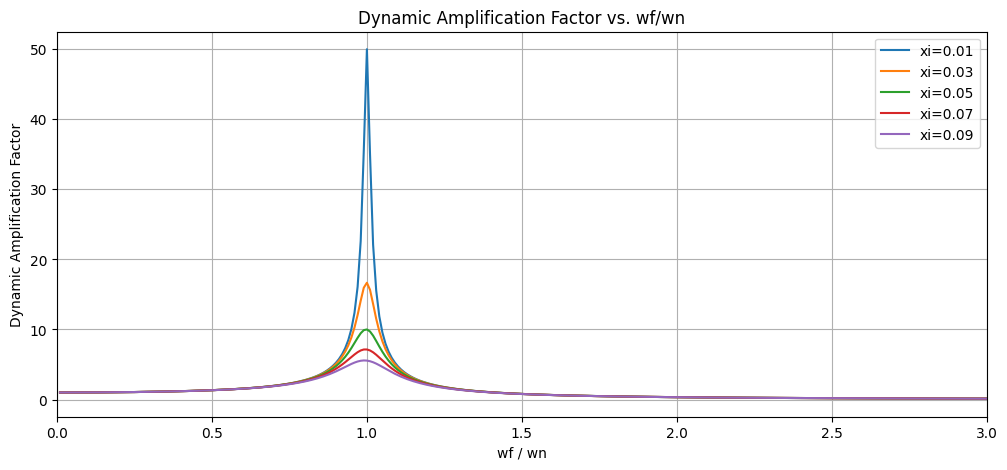

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(wf/wn,daf[:,0], label=f'xi={xi[0]:.2f}')
plt.plot(wf/wn,daf[:,1], label=f'xi={xi[1]:.2f}')
plt.plot(wf/wn,daf[:,2], label=f'xi={xi[2]:.2f}')
plt.plot(wf/wn,daf[:,3], label=f'xi={xi[3]:.2f}')
plt.plot(wf/wn,daf[:,4], label=f'xi={xi[4]:.2f}')
plt.legend()
plt.xlabel('wf / wn')
plt.ylabel('Dynamic Amplification Factor')
plt.title('Dynamic Amplification Factor vs. wf/wn')
plt.grid()
plt.xlim(0,3)
plt.show()